In [1]:
# ── Cell 1: imports ───────────────────────────────────────────────────────────
%pip install rasterio
%pip install elevation
import io
import warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.mask
import rasterio.features
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from shapely.geometry import shape, mapping
import osmnx as ox

warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Cell 2: download SRTM elevation raster for the Netherlands ────────────────
import zipfile

# SRTM tile covering the Netherlands (tile 38_02 from CGIAR)
dem_zip_url = (
    "https://srtm.csi.cgiar.org/wp-content/uploads/files/"
    "srtm_5x5/TIFF/srtm_38_02.zip"
)

print("Downloading DEM tile (~25MB, may take a moment)...")
response = requests.get(dem_zip_url, verify=False, timeout=120, stream=True)

with open("srtm_38_02.zip", "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

# Extract the GeoTIFF from the zip
with zipfile.ZipFile("srtm_38_02.zip", "r") as z:
    tif_names = [n for n in z.namelist() if n.endswith(".tif")]
    z.extract(tif_names[0], ".")
    dem_path = tif_names[0]

print(f"DEM extracted: {dem_path}")

DEM extracted: srtm_38_02.tif


In [3]:
# ── Cell 3: load municipality boundaries ─────────────────────────────────────
muni_url = "https://cartomap.github.io/nl/wgs84/gemeente_2023.geojson"
response = requests.get(muni_url, verify=False, timeout=60)
municipalities = gpd.read_file(io.BytesIO(response.content))
municipalities = municipalities[["statnaam", "geometry"]].rename(
    columns={"statnaam": "name"}
)
print(f"Municipalities loaded: {len(municipalities)}")
print(f"CRS: {municipalities.crs}")

Municipalities loaded: 342
CRS: EPSG:4326


In [4]:
# ── Cell 4: reproject municipalities to match raster CRS ─────────────────────
with rasterio.open(dem_path) as src:
    raster_crs = src.crs
    print(f"Raster CRS: {raster_crs}")
    print(f"Raster bounds: {src.bounds}")
    print(f"Raster shape: {src.shape}")

municipalities = municipalities.to_crs(raster_crs)
print(f"Municipalities reprojected to: {municipalities.crs}")

Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=5.0, bottom=50.0, right=10.0, top=55.0)
Raster shape: (6000, 6000)
Municipalities reprojected to: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [6]:
# ── Cell 5: define coastal zone by buffering municipality boundary ─────────────
# Fix any invalid geometries
municipalities["geometry"] = municipalities.geometry.buffer(0)

# Dissolve all municipalities into one Netherlands polygon
netherlands = municipalities.dissolve().to_crs("EPSG:28992")

# Buffer the outer boundary by 10km to define the coastal zone
coastal_zone = netherlands.boundary.buffer(10000).unary_union

coastal_gdf = gpd.GeoDataFrame(geometry=[coastal_zone], crs="EPSG:28992")
coastal_gdf = coastal_gdf.to_crs(raster_crs)

print(f"Coastal buffer created: {coastal_gdf.geometry.geom_type.values[0]}")
print(f"Coastal zone area: {coastal_gdf.geometry.area.sum():.2e} sq degrees")

Coastal buffer created: Polygon
Coastal zone area: 4.47e+00 sq degrees


In [7]:
# ── Cell 6: mask raster to coastal buffer ─────────────────────────────────────
with rasterio.open(dem_path) as src:
    shapes = [mapping(coastal_gdf.geometry[0])]
    masked_data, masked_transform = rasterio.mask.mask(
        src, shapes, crop=True, nodata=-9999
    )
    masked_meta = src.meta.copy()

elevation_array = masked_data[0].astype(float)
elevation_array[elevation_array == -9999] = np.nan
print(f"Masked elevation array shape: {elevation_array.shape}")
print(f"Elevation range: {np.nanmin(elevation_array):.1f} – {np.nanmax(elevation_array):.1f} m")

Masked elevation array shape: (3580, 2842)
Elevation range: -41.0 – 372.0 m


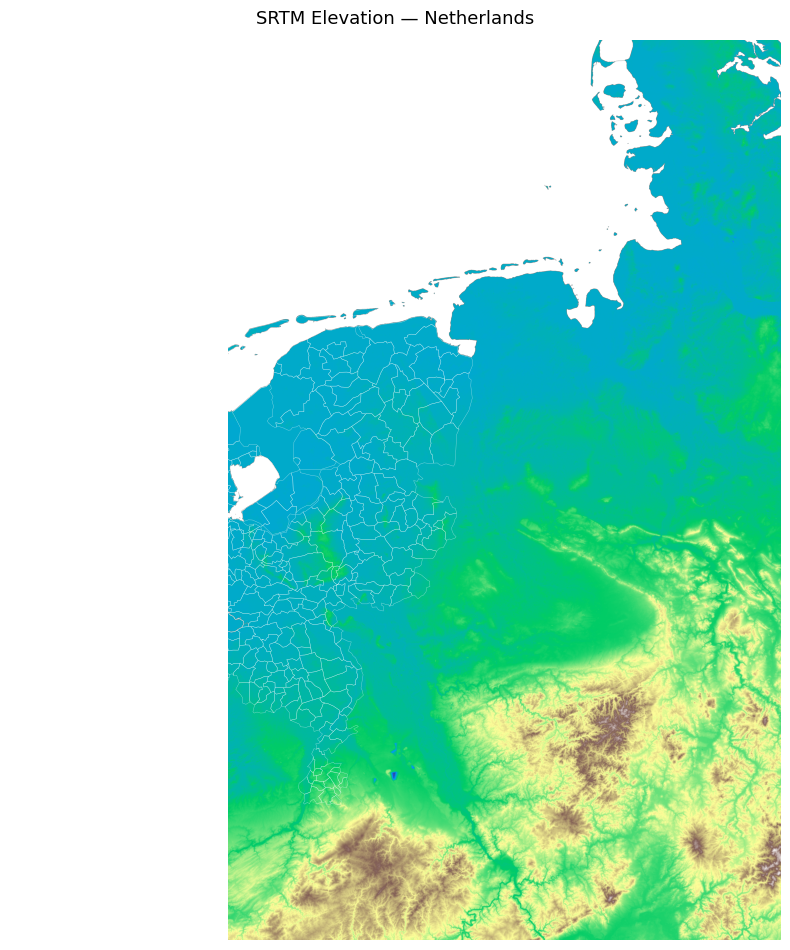

In [8]:
# ── Cell 7: plot elevation map ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 10))

from rasterio.plot import show as rshow
with rasterio.open(dem_path) as src:
    rshow(src, ax=ax, cmap="terrain", title="Netherlands — SRTM Elevation")

municipalities.boundary.plot(ax=ax, color="white", linewidth=0.3, alpha=0.5)
ax.set_title("SRTM Elevation — Netherlands", fontsize=13, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("elevation_map.png", dpi=150, bbox_inches="tight")
plt.show()

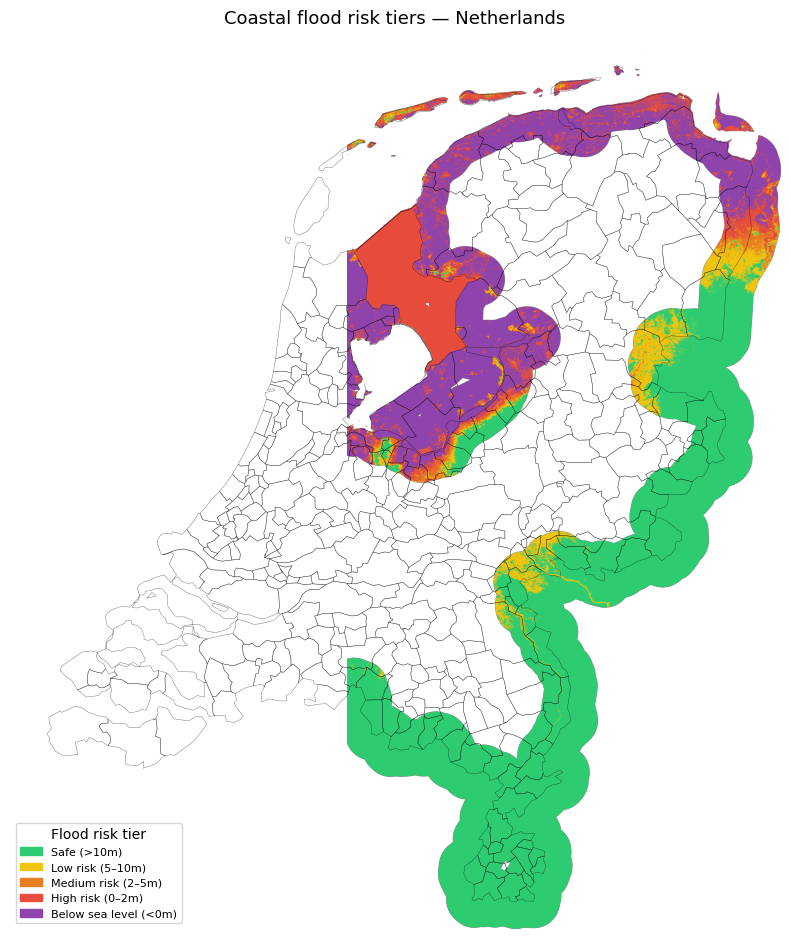

In [9]:
# ── Cell 8: classify elevation into flood risk tiers ─────────────────────────
# Risk tiers based on elevation above sea level
risk = np.full(elevation_array.shape, np.nan)
risk[elevation_array > 10]                              = 0  # safe
risk[(elevation_array > 5) & (elevation_array <= 10)]  = 1  # low risk
risk[(elevation_array > 2) & (elevation_array <= 5)]   = 2  # medium risk
risk[(elevation_array >= 0) & (elevation_array <= 2)]  = 3  # high risk
risk[elevation_array < 0]                              = 4  # below sea level

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
labels = ["Safe (>10m)", "Low risk (5–10m)", "Medium risk (2–5m)",
          "High risk (0–2m)", "Below sea level (<0m)"]
cmap   = mcolors.ListedColormap(colors)

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(risk, cmap=cmap, vmin=0, vmax=4,
               extent=[
                   masked_transform.c,
                   masked_transform.c + masked_transform.a * risk.shape[1],
                   masked_transform.f + masked_transform.e * risk.shape[0],
                   masked_transform.f,
               ])
municipalities.boundary.plot(ax=ax, color="black", linewidth=0.3, alpha=0.6)
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, loc="lower left", fontsize=8, title="Flood risk tier")
ax.set_title("Coastal flood risk tiers — Netherlands", fontsize=13, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("risk_tiers.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Cell 9: vectorise risk raster → high-risk polygons ───────────────────────
# Write classified raster to temp file so we can use rasterio.features.shapes
masked_meta.update({"dtype": "float32", "count": 1, "nodata": np.nan})

high_risk_shapes = []
transform = masked_transform

risk_int = np.where(risk == 3, 1, 0).astype(np.uint8)  # high risk = 1
for geom, val in rasterio.features.shapes(risk_int, transform=transform):
    if val == 1:
        high_risk_shapes.append(shape(geom))

high_risk_gdf = gpd.GeoDataFrame(
    geometry=high_risk_shapes, crs=raster_crs
)
print(f"High-risk polygons extracted: {len(high_risk_gdf)}")

High-risk polygons extracted: 14172


In [11]:
# ── Cell 10: overlay high-risk polygons with municipalities ───────────────────
municipalities["total_area_m2"] = municipalities.to_crs("EPSG:28992").geometry.area

intersection = gpd.overlay(
    high_risk_gdf[["geometry"]],
    municipalities[["name", "geometry"]],
    how="intersection",
)
intersection["high_risk_area"] = intersection.to_crs("EPSG:28992").geometry.area

risk_by_muni = (
    intersection.groupby("name")["high_risk_area"]
    .sum()
    .reset_index()
)

municipalities = municipalities.merge(risk_by_muni, on="name", how="left")
municipalities["high_risk_area"]  = municipalities["high_risk_area"].fillna(0)
municipalities["high_risk_pct"]   = (
    municipalities["high_risk_area"] / municipalities["total_area_m2"] * 100
).clip(upper=100)

print(
    municipalities[["name", "high_risk_pct"]]
    .sort_values("high_risk_pct", ascending=False)
    .head(15)
)

                name  high_risk_pct
6            Ameland      57.077869
14      Terschelling      40.988977
12   Schiermonnikoog      36.901494
122            Hoorn      36.065492
321     Gooise Meren      31.073503
83        Amersfoort      30.054063
31            Kampen      28.501145
55            Elburg      28.222092
7          Harlingen      28.074687
88            Eemnes      26.747960
333     Het Hogeland      24.936470
64           Nijkerk      24.726095
325      Westerwolde      24.549359
87        Bunschoten      23.936419
114        Enkhuizen      22.610411


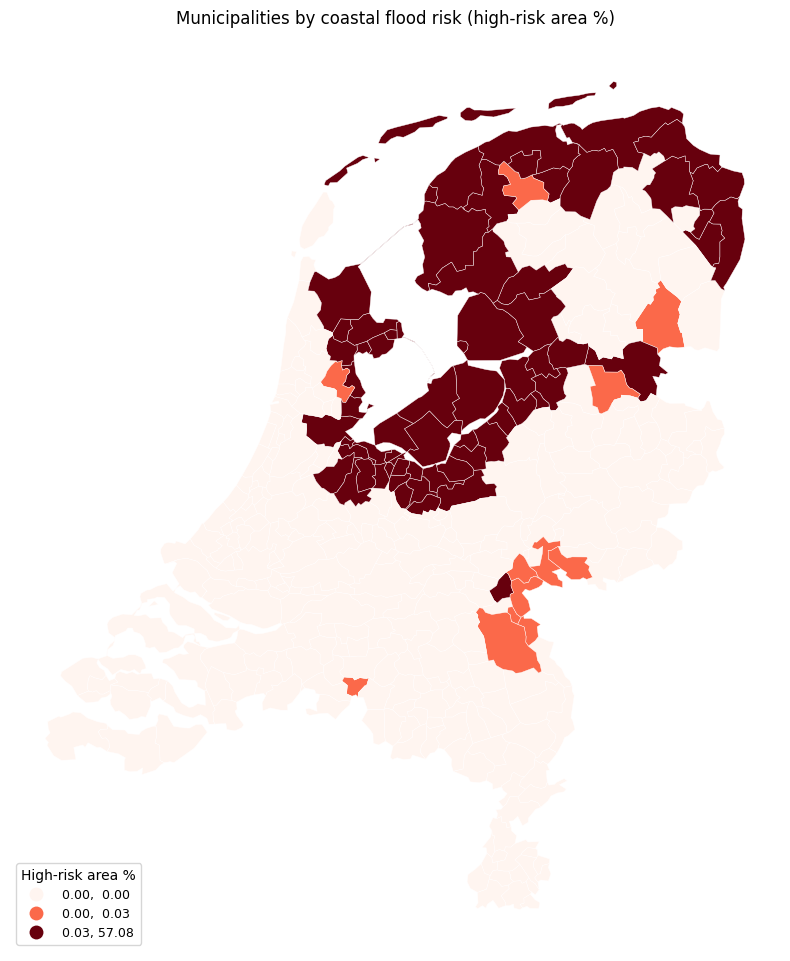

In [12]:
# ── Cell 11: choropleth — high-risk % per municipality ───────────────────────
muni_plot = municipalities.to_crs("EPSG:28992")

fig, ax = plt.subplots(figsize=(8, 10))
muni_plot.plot(
    column="high_risk_pct",
    ax=ax,
    cmap="Reds",
    scheme="quantiles",
    k=5,
    legend=True,
    legend_kwds={"title": "High-risk area %", "loc": "lower left", "fontsize": 9},
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={"color": "#eeeeee"},
)
ax.set_title("Municipalities by coastal flood risk (high-risk area %)",
             fontsize=12, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("flood_risk_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()